# Candidate Variable Star Detection DIASource

**Goals**
1) 

---

**Summary Table**

| Metric / Field             | Description                                                   |
|----------------------------|---------------------------------------------------------------|
| `coord_ra`, `coord_dec`    | Right Ascension and Declination (ICRS)                        |
| `midPointTai`              | Time of observation in TAI                                    |
| `psFlux`, `psFluxErr`      | PSF flux and flux uncertainty for each observation            |
| `filterName`               | LSST filter used (e.g. g, r, i)                               |
| `psfFlux_flag`            | Quality control flags for removing unreliable measurements    |
| `diaObjectId`              | Foreign key to group detections into single light curves      |
| `diaSourceId`              | Unique ID for each observation                               |

---

**Tasks**
1) Outlier Detection: Flux Jump Test (plots examples where large flux changes exceeds a certain threshold and can help detect flags or artifacts)

In [39]:
# libraries, imports, etc
import numpy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns

print('numpy version: ', numpy.__version__)
print('matplotlib version: ', matplotlib.__version__)

numpy version:  2.2.6
matplotlib version:  3.10.3


In [40]:
# TAP Service 
from lsst.rsp import get_tap_service, retrieve_query

service = get_tap_service("tap")
assert service is not None

In [41]:
varstars = pd.read_csv("variablestar_subset.csv")
dia_ids = varstars["diaObjectId"].unique()

In [43]:
# making DiaSource so we can merge it with vs subset
query = """SELECT coord_dec, coord_ra, diaObjectId,
        midPointMjdTai, psfFlux, psfFluxErr,
        psfFlux_flag, psfFlux_flag_edge
        FROM dp1.DiaSource"""
job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'

diasource = job.fetch_result().to_table().to_pandas()

Job phase is COMPLETED


In [44]:
diasource.to_csv("diasource.csv", index = False)

In [45]:
# the merge
varstars = varstars.dropna(subset=["diaObjectId"])
diasource = diasource.dropna(subset=["diaObjectId"])

common_ids = set(diasource["diaObjectId"]) & set(varstars["diaObjectId"])
print("Number of common diaObjectIds:", len(common_ids))

filtered_diasource = diasource[diasource["diaObjectId"].isin(varstars["diaObjectId"])]

filtered_diasource = filtered_diasource.merge(
    varstars[["diaObjectId", "Class"]],
    on="diaObjectId",
    how="left"
)

print("Filtered DiaSource rows:", len(filtered_diasource))
print("Unique diaObjectIds in filtered set:", filtered_diasource["diaObjectId"].nunique())

filtered_diasource.to_csv("vs_diasource.csv", index = False)

Number of common diaObjectIds: 550
Filtered DiaSource rows: 8597
Unique diaObjectIds in filtered set: 550


In [46]:
vs_diasource = pd.read_csv("vs_diasource.csv")

We start using functions from here because DiaObject was doing single-snapshot metadata checks, but we need to start breaking it down per object since we are going to do time series data per object, aka light curves. We need to repeat this same analysis for many stars and functions will help make that repeatable and modular, where we just pass a different object_id.

In [59]:
classes = ['RRLyrae', 'Cepheid', 'LPV']
jump_stats = [compute_flux_jump_stats(vs_diasource, cls) for cls in classes]

jump_df = pd.DataFrame(jump_stats)
display(jump_df)

thresholds = {
    stat['class']: stat['upper_iqr_threshold']
    for stat in jump_stats
}

print("Flux jump thresholds by class (IQR-based):")
for cls, thresh in thresholds.items():
    print(f"{cls}: {thresh:.3f} mag")

,class,n_jumps,median_jump,mean_jump,std_jump,iqr,upper_iqr_threshold,90th_percentile,95th_percentile,max_jump
0,RRLyrae,1426,0.150176,0.411060,0.785697,0.325516,0.863034,1.023014,1.804036,8.524458
1,Cepheid,75,0.218641,0.445274,0.561239,0.534638,1.421069,1.243478,1.447949,2.540097
2,LPV,1797,0.605547,1.073539,1.275831,1.199706,3.227765,2.773607,3.721340,12.497244


Flux jump thresholds by class (IQR-based):
RRLyrae: 0.863 mag
Cepheid: 1.421 mag
LPV: 3.228 mag


In [54]:
# flux to mag (both negative and positive values)

vs_diasource["mag"] = -2.5 * np.log10(vs_diasource["psfFlux"]) + 25
vs_diasource["mag_err"] = 1.0857 * vs_diasource["psfFluxErr"] / vs_diasource["psfFlux"]


# Functions that are gonna be graphed

def plot_light_curve(df, object_id, object_class):
    obj_df = df[df['diaObjectId'] == object_id].sort_values('midPointMjdTai')

    if object_class == "RRLyrae":
        first_night = int(obj_df['midPointMjdTai'].iloc[0])
        obj_df = obj_df[(obj_df['midPointMjdTai'] >= first_night) & (obj_df['midPointMjdTai'] < first_night + 1)]
        print(f"RRLyrae: Using observations from night {first_night}")

    plt.errorbar(obj_df['midPointMjdTai'], obj_df['mag'], yerr=obj_df['mag_err'], fmt='o', alpha=0.6)
    plt.xlabel('midPointMjdTai')
    plt.ylabel('magnitude')
    plt.title(f'Light Curve for objectId {object_id}')
    plt.grid(True)
    plt.show()

def plot_rolling_mean(df, object_id, object_class, window=5):
    obj_df = df[df['diaObjectId'] == object_id].sort_values('midPointMjdTai').copy()

    if object_class == "RRLyrae":
        first_night = int(obj_df['midPointMjdTai'].iloc[0])
        obj_df = obj_df[(obj_df['midPointMjdTai'] >= first_night) & (obj_df['midPointMjdTai'] < first_night + 1)]
        print(f"RRLyrae: Using observations from night {first_night}")
        # You can skip rolling mean for RRLyrae if not meaningful
        plt.plot(obj_df['midPointMjdTai'], obj_df['mag'], 'o', alpha=0.6, label='Magnitude')
    else: 
        obj_df['rolling_psfFlux'] = obj_df['psfFlux'].rolling(window=window, center=True).mean()
        valid_rolling = obj_df['rolling_psfFlux'] > 0
        obj_df.loc[valid_rolling, 'rolling_mag'] = -2.5 * np.log10(obj_df.loc[valid_rolling, 'rolling_psfFlux']) + 25

        plt.plot(obj_df['midPointMjdTai'], obj_df['mag'], 'o', alpha=0.4, label='Raw Magnitude')
        plt.plot(obj_df['midPointMjdTai'], obj_df['rolling_mag'], '-', label=f'Rolling Mean (window={window})')

    plt.xlabel('midPointMjdTai')
    plt.ylabel('magnitude')
    plt.title(f'Rolling Mean Light Curve for objectId {object_id}')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_flux_jumps(df, object_id, object_class, threshold=None):
    # Set default threshold based on class if not provided
    if threshold is None:
        class_thresholds = {
            "RRLyrae": 0.14,
            "Cepheid": 0.22,
            "LPV": 0.61
        }
        threshold = class_thresholds.get(object_class, 0.5)
    
    obj_df = df[df['diaObjectId'] == object_id].sort_values('midPointMjdTai')

    if object_class == "RRLyrae":
        first_night = int(obj_df['midPointMjdTai'].iloc[0])
        obj_df = obj_df[(obj_df['midPointMjdTai'] >= first_night) & (obj_df['midPointMjdTai'] < first_night + 1)]
        print(f"RRLyrae: Using observations from night {first_night}")
    
    flux_diff = np.abs(np.diff(obj_df['mag']))
    jump_indices = np.where(flux_diff > threshold)[0]

    if len(jump_indices) == 0:
        print(f"No large flux jumps detected (threshold = {threshold:.3f} mag).")
    else:
        print(f"{len(jump_indices)} flux jumps detected (threshold = {threshold:.3f} mag).")
    
    plt.plot(obj_df['midPointMjdTai'], obj_df['mag'], 'o-')
    for idx in jump_indices:
        plt.axvline(obj_df['midPointMjdTai'].iloc[idx+1], color='red', linestyle='--')
    plt.xlabel('midPointMjdTai')
    plt.ylabel('magnitude')
    plt.title(f'Flux Jump Detection for objectId {object_id}')
    plt.grid(True)
    plt.show()

# Functions for Checks

def plot_spatial_coverage(object_df):
    plt.scatter(object_df['coord_ra'], object_df['coord_dec'], s=1, alpha=0.5)
    plt.xlabel('RA')
    plt.ylabel('Dec')
    plt.title('Sky Position: RA vs Dec')
    plt.grid(True)
    plt.show()

def plot_observation_logdensity(diasource_df):
    counts = diasource_df.groupby('diaObjectId').size()
    plt.hist(counts, bins=30, log=True)
    plt.xlabel('Number of Observations')
    plt.ylabel('Number of Stars')
    plt.title('Observation Density per Star (Log Scale)')
    plt.grid(True)
    plt.show()

def plot_observation_density(diasource_df):
    counts = diasource_df.groupby('diaObjectId').size()
    plt.hist(counts, bins=30)
    plt.xlabel('Number of Observations')
    plt.ylabel('Number of Stars')
    plt.title('Observation Density per Star')
    plt.grid(True)
    plt.show()

def plot_time_deltas(df, object_id):
    obj_df = df[df['diaObjectId'] == object_id].sort_values('midPointMjdTai')
    deltas = np.diff(obj_df['midPointMjdTai'])
    plt.hist(deltas, bins=20)
    plt.xlabel('Time Gap (days)')
    plt.ylabel('Frequency')
    plt.title(f'Time Gaps Between Observations for objectId {object_id}')
    plt.grid(True)
    plt.show()

def plot_flux_logdistribution(df, object_id=None):
    if object_id:
        df = df[df['diaObjectId'] == object_id]
    plt.hist(df['mag'], bins=50, log=True)
    plt.xlabel('magnitude')
    plt.ylabel('Count')
    plt.title(f'Flux Distribution {"(Log Scale)" }')
    plt.grid(True)
    plt.show()

# get a random one for graphing to see if it works over multiple stars
def get_random_object_id(df, min_observations=5):
    counts = df['diaObjectId'].value_counts()
    eligible_ids = counts[counts >= min_observations].index.to_numpy()
    
    np.random.seed(None) 
    selected = np.random.choice(eligible_ids)
    selected_class = df.loc[df['diaObjectId'] == selected, 'Class'].mode().iloc[0]
    print("Randomly selected:", selected_class)
    print("Class:", selected_class)
    return selected, selected_class

# Used to view statistics, decided to go with median due to skew
def compute_flux_jump_stats(df, object_class, min_obs=5):
    obj_ids = df[df['Class'] == object_class]['diaObjectId'].unique()
    jump_values = []

    for obj_id in obj_ids:
        obj_df = df[df['diaObjectId'] == obj_id].sort_values('midPointMjdTai')
        if len(obj_df) < min_obs:
            continue
        delta_mag = np.abs(np.diff(obj_df['mag'].values)) 
        jump_values.extend(delta_mag)

    jump_values = np.array(jump_values)
    return {
        'class': object_class,
        'mean_jump': np.mean(jump_values),
        'std_jump': np.std(jump_values),
        'median_jump': np.median(jump_values),
        'max_jump': np.max(jump_values),
        '90th_percentile': np.percentile(jump_values, 90),
        '95th_percentile': np.percentile(jump_values, 95),
        'n_jumps': len(jump_values)
    }

classes = ['RRLyrae', 'Cepheid', 'LPV']
jump_stats = [compute_flux_jump_stats(vs_diasource, cls) for cls in classes]
pd.DataFrame(jump_stats)

Ranges will overlap so calculating thresholds will be a bit more difficult, I've determined some threshold cutoffs based on the medians of the average magnitude jump. 

For RR Lyrae, we calculate magnitude jumps within a night, for LPV and Cepheids it's night to night. When we go to the unlabeled data, then it will be doing both to see if there were any jumps in general based on observations.

NOTE: DP1 doesn't have all the observations. We have noted how many had notable magnitude jumps based on these thresholds, but some observations were recorded during flat phases so in the dataset, there may be no detected jumps.

Randomly selected: LPV
Class: LPV


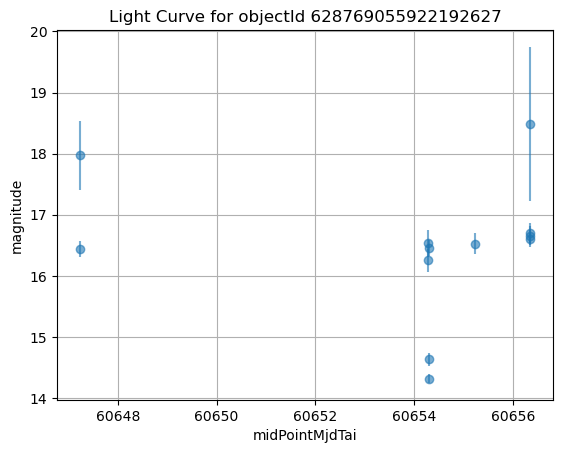

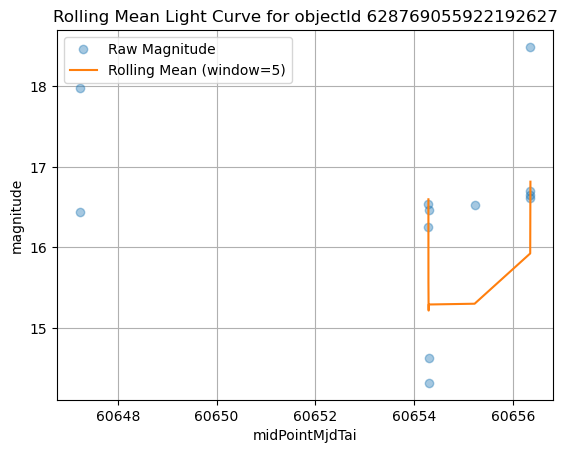

5 flux jumps detected (threshold = 0.610 mag).


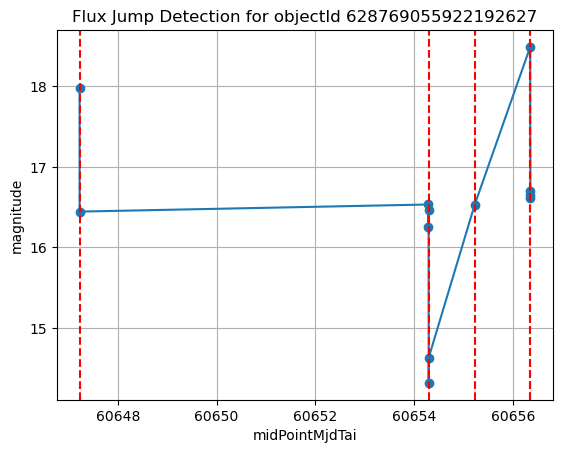

In [61]:
# Testing Graphs

object_id, object_class = get_random_object_id(vs_diasource)

plot_light_curve(vs_diasource, object_id, object_class)
plot_rolling_mean(vs_diasource, object_id, object_class)
plot_flux_jumps(vs_diasource, object_id, object_class)

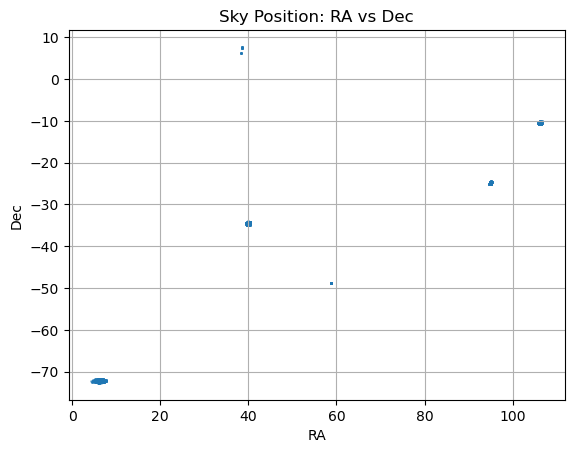

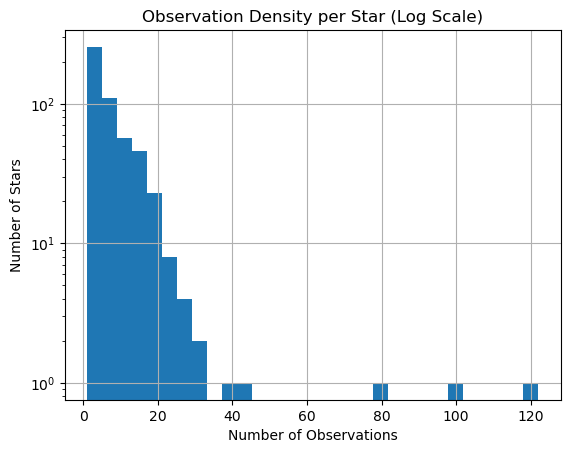

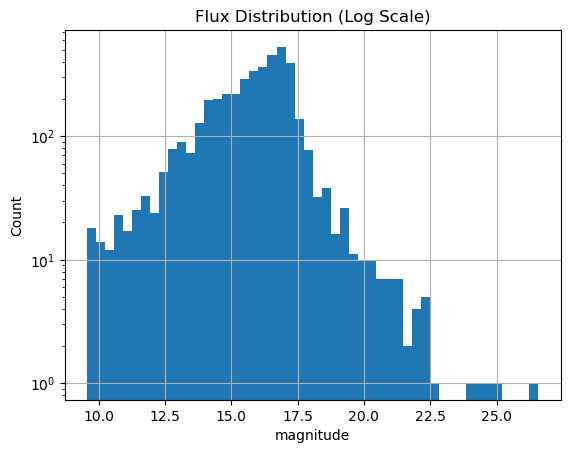

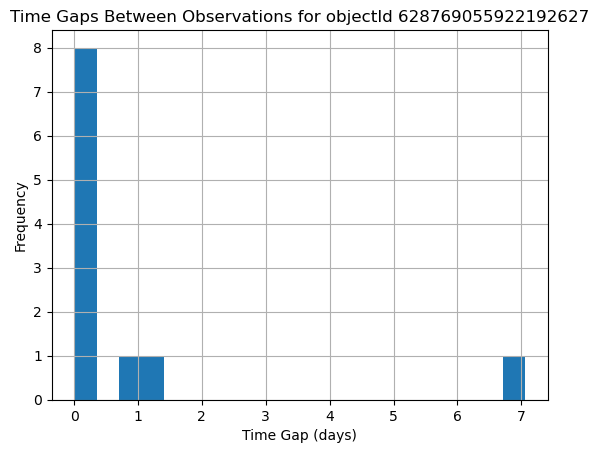

In [68]:
# Testing Misc

plot_spatial_coverage(vs_diasource) 
plot_observation_logdensity(vs_diasource) 
plot_flux_logdistribution(vs_diasource, object_id=None) # overall
plot_time_deltas(vs_diasource, object_id)

In [66]:
# function that also adds the jump count and "is jump or not" to the vs_diasource dataset
def count_flux_jumps(df, object_id, object_class, thresholds=None, min_obs=5):
    obj_df = df[df['diaObjectId'] == object_id].sort_values('midPointMjdTai')
    
    if len(obj_df) < min_obs:
        return 0
        
    if thresholds is None:
        thresholds = {
            "RRLyrae": 0.14,
            "Cepheid": 0.225,
            "LPV": 0.61
            # median - 0.14, 0.22, 0.61
        }

    threshold = thresholds.get(object_class, 0.5) # in case it can't detect a class, will be used for unvariable stars in DP1

    if object_class == "RRLyrae":
        first_night = int(obj_df['midPointMjdTai'].iloc[0])
        obj_df = obj_df[(obj_df['midPointMjdTai'] >= first_night) & 
                        (obj_df['midPointMjdTai'] < first_night + 1)]

    flux_diff = np.abs(np.diff(obj_df['mag']))
    jump_indices = np.where(flux_diff > threshold)[0]

    return len(jump_indices)

unique_objects = vs_diasource[['diaObjectId', 'Class']].drop_duplicates()

# count them jumps ong
unique_objects['n_flux_jumps'] = unique_objects.apply(
    lambda row: count_flux_jumps(vs_diasource, row['diaObjectId'], row['Class']),
    axis=1
)

# just in case no one cares about the amount of jumps 
unique_objects['has_flux_jump'] = (unique_objects['n_flux_jumps'] > 0).astype(int)

vs_diasource = vs_diasource.drop(columns=['n_flux_jumps', 'has_flux_jump'], errors='ignore')
vs_diasource = vs_diasource.merge(unique_objects, on=['diaObjectId', 'Class'], how='left')

vs_diasource.to_csv("vs_diasource.csv", index=False)

print(vs_diasource[['diaObjectId', 'Class', 'n_flux_jumps', 'has_flux_jump']].drop_duplicates().head())

           diaObjectId    Class  n_flux_jumps  has_flux_jump
0   579578142646075468  RRLyrae             0              0
16  579575256428052608  RRLyrae             1              1
17  579575256428052807  RRLyrae             1              1
18  579575256428052935  RRLyrae             4              1
19  579575256428052817  RRLyrae             0              0


In [64]:
print("Objects with zero jumps:", (unique_objects['n_flux_jumps'] == 0).sum())
print("Total objects:", len(unique_objects))

Objects with zero jumps: 230
Total objects: 512


In [65]:
unique_objects[unique_objects['n_flux_jumps'] == 0].head()

,diaObjectId,Class,n_flux_jumps,has_flux_jump
3,579578142646075468,RRLyrae,0,0
28,579575256428052817,RRLyrae,0,0
59,579575256428053274,LPV,0,0
74,579574569233285165,LPV,0,0
79,579575187708576287,LPV,0,0


## Findings


## Summary


## Results & Interpretations
